# 🚗 Toronto Traffic Collision Severity Prediction
## Notebook 5 of 5 — SHAP Explainability & Geospatial Analysis

**Author:** Nishi Bhavesh Patel | Student ID: 501356244

---
### What this notebook does:
- Loads the trained XGBoost model from Notebook 4
- Computes SHAP values to explain predictions
- Produces global and local SHAP visualizations
- Builds static collision map (VS Code compatible)
- Builds interactive Folium maps saved as HTML
- Runs DBSCAN spatial clustering to find high-risk zones
- Prints final project summary

### Input files:
- `trained_models.pkl` (from Notebook 4)
- `X_test.csv`, `y_test.csv` (from Notebook 4)
- `collisions_cleaned.csv` (from Notebook 2)

---

## Step 1 — Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import pickle
import os
import webbrowser
warnings.filterwarnings('ignore')

import shap
import folium
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN

# ── File paths ──
CLEANED_FILE  = '../MRP - Final Sem/Data/collisions_cleaned.csv'
MODELS_FOLDER = '../MRP - Final Sem/Models/'
PLOTS_FOLDER  = '../MRP - Final Sem/Plots/'
MAPS_FOLDER   = '../MRP - Final Sem/Maps/'

os.makedirs(PLOTS_FOLDER, exist_ok=True)
os.makedirs(MAPS_FOLDER,  exist_ok=True)

severity_labels = {0:'Minor', 1:'Major', 2:'Fatal'}
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded!')

Libraries loaded!


---
## Step 2 — Load Models and Test Data

In [19]:
# Load trained models
with open(f'{MODELS_FOLDER}trained_models.pkl', 'rb') as f:
    trained_models = pickle.load(f)
print(f'Models loaded: {list(trained_models.keys())}')

# Load model comparison results
results_df      = pd.read_csv(f'{MODELS_FOLDER}model_results.csv')
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
print(f'Best model: {best_model_name}')

Models loaded: ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'Neural Network']
Best model: XGBoost


In [20]:
# Load test set
X_test = pd.read_csv(f'{MODELS_FOLDER}X_test.csv')
y_test = pd.read_csv(f'{MODELS_FOLDER}y_test.csv').squeeze()
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

# Load cleaned data for maps
df = pd.read_csv(CLEANED_FILE, low_memory=False)
print(f'Full data loaded: {df.shape}')

X_test: (101559, 37)
y_test: (101559,)
Full data loaded: (677056, 48)


---
## Step 3 — Compute SHAP Values

In [21]:
shap_model = trained_models['XGBoost']

# Sample 2000 rows from test set (SHAP is slow on large datasets)
sample_idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
X_shap     = X_test.iloc[sample_idx]

print('Computing SHAP values (takes ~1-2 minutes)...')
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
print(f'Done! Shape: {np.array(shap_values).shape}')

Computing SHAP values (takes ~1-2 minutes)...
Done! Shape: (2000, 37, 3)


In [22]:
# Reshape SHAP values to per-class arrays
# Shape (2000, features, 3) → separate array per class
shap_values_minor = shap_values[:, :, 0]
shap_values_major = shap_values[:, :, 1]
shap_values_fatal = shap_values[:, :, 2]

print(f'Per-class SHAP shape: {shap_values_fatal.shape}')
print('✅ Ready for plots!')

Per-class SHAP shape: (2000, 37)
✅ Ready for plots!


---
## Step 4 — SHAP Visualizations

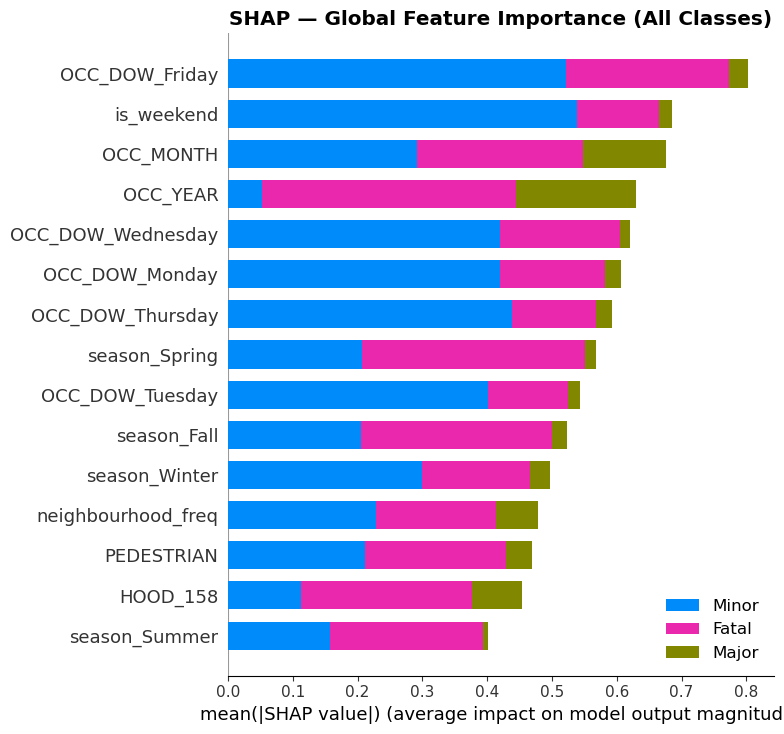

In [23]:
# SHAP 1: Global importance — all classes
plt.figure(figsize=(10,7))
shap.summary_plot(
    [shap_values_minor, shap_values_major, shap_values_fatal],
    X_shap, plot_type='bar',
    class_names=['Minor','Major','Fatal'],
    max_display=15, show=False
)
plt.title('SHAP — Global Feature Importance (All Classes)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_12_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

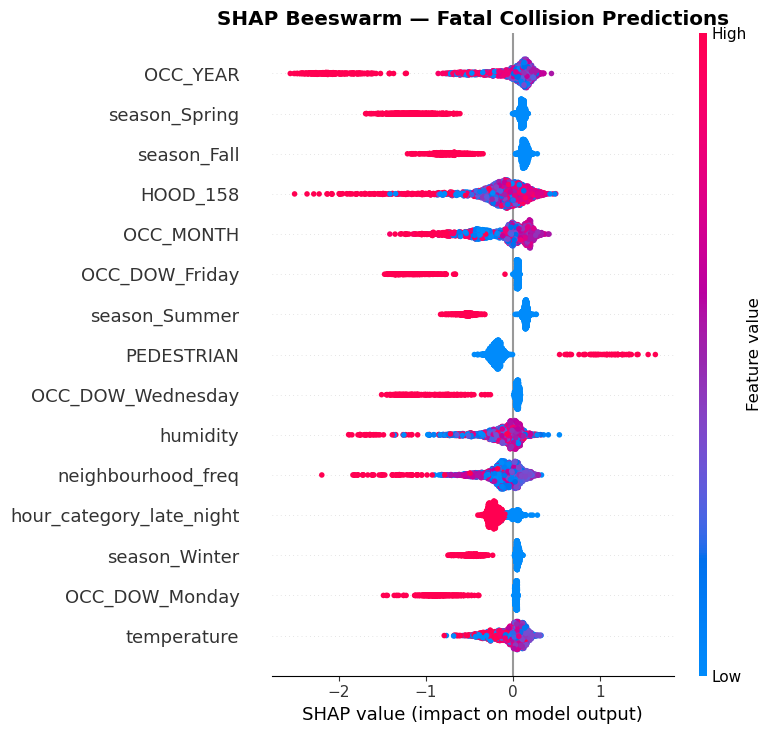

In [24]:
# SHAP 2: Beeswarm — Fatal class
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values_fatal, X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm — Fatal Collision Predictions', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_13_shap_fatal_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

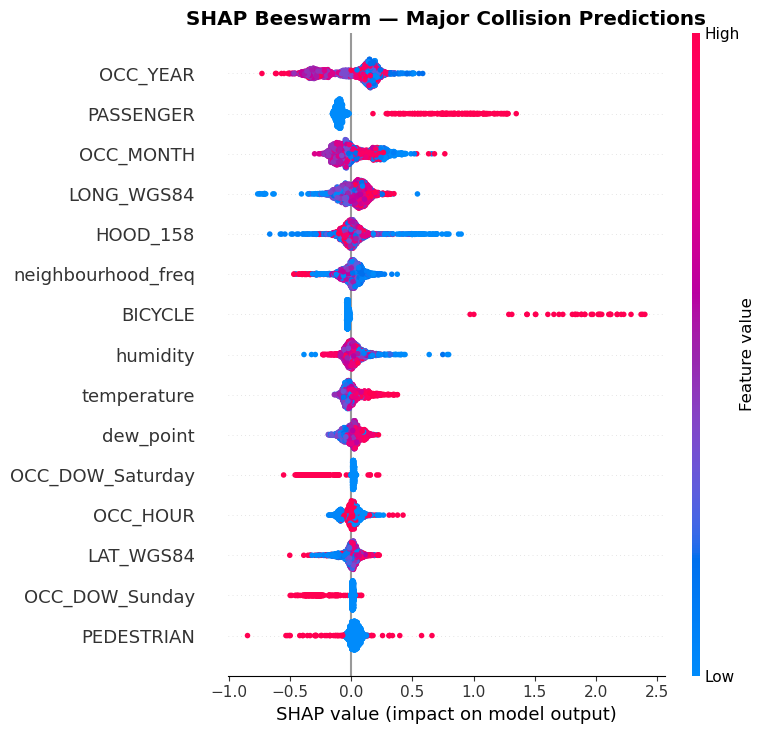

In [25]:
# SHAP 3: Beeswarm — Major class
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values_major, X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm — Major Collision Predictions', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_14_shap_major_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

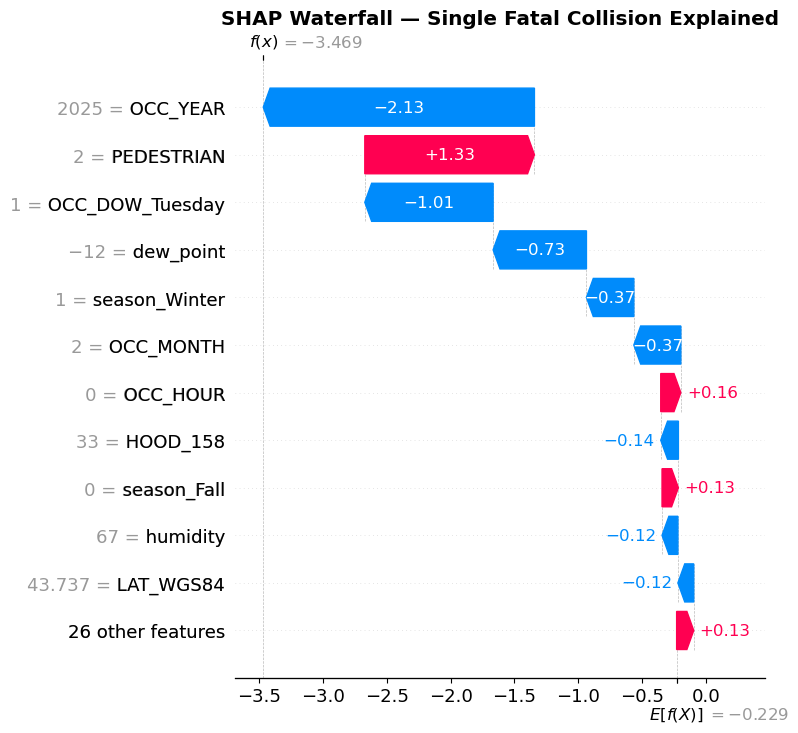

In [27]:
# SHAP 4: Waterfall — single fatal collision explained
fatal_indices = np.where(y_test.iloc[sample_idx].values == 2)[0]
if len(fatal_indices) > 0:
    idx = fatal_indices[0]
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_fatal[idx],
            base_values=explainer.expected_value[2],
            data=X_shap.iloc[idx].values,
            feature_names=X_shap.columns.tolist()
        ), max_display=12, show=False
    )
    plt.title('SHAP Waterfall — Single Fatal Collision Explained', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_FOLDER}plot_15_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fatal collisions in sample — re-run with larger sample size')

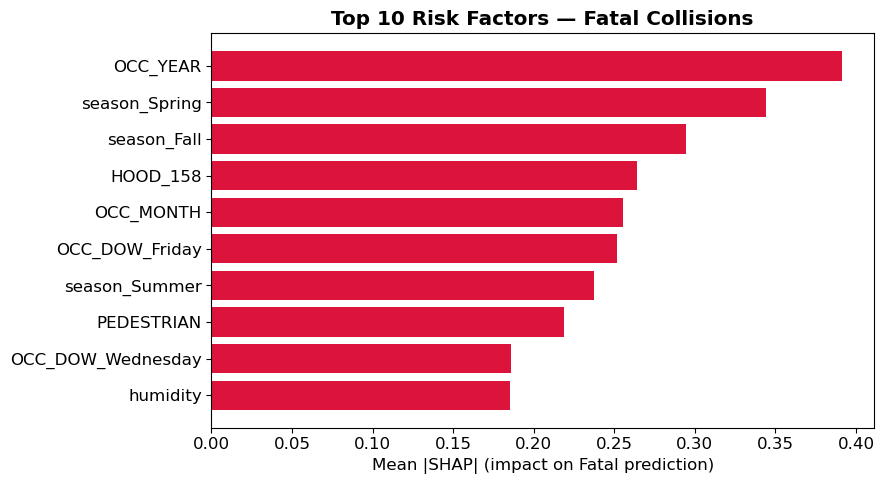

          Feature  Mean |SHAP|
         OCC_YEAR     0.391555
    season_Spring     0.344378
      season_Fall     0.294580
         HOOD_158     0.264247
        OCC_MONTH     0.255573
   OCC_DOW_Friday     0.251521
    season_Summer     0.237417
       PEDESTRIAN     0.218565
OCC_DOW_Wednesday     0.185855
         humidity     0.184972


In [28]:
# SHAP 5: Top 10 risk factors for Fatal class
shap_importance = pd.DataFrame({
    'Feature':     X_shap.columns,
    'Mean |SHAP|': np.abs(shap_values_fatal).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(shap_importance['Feature'][::-1],
        shap_importance['Mean |SHAP|'][::-1], color='crimson')
ax.set_xlabel('Mean |SHAP| (impact on Fatal prediction)')
ax.set_title('Top 10 Risk Factors — Fatal Collisions', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_16_shap_top10_fatal.png', dpi=150, bbox_inches='tight')
plt.show()
print(shap_importance.to_string(index=False))

---
## Step 5 — Static Collision Map

Folium maps don't render in VS Code — use static matplotlib map instead. HTML maps are still saved and can be opened in browser.

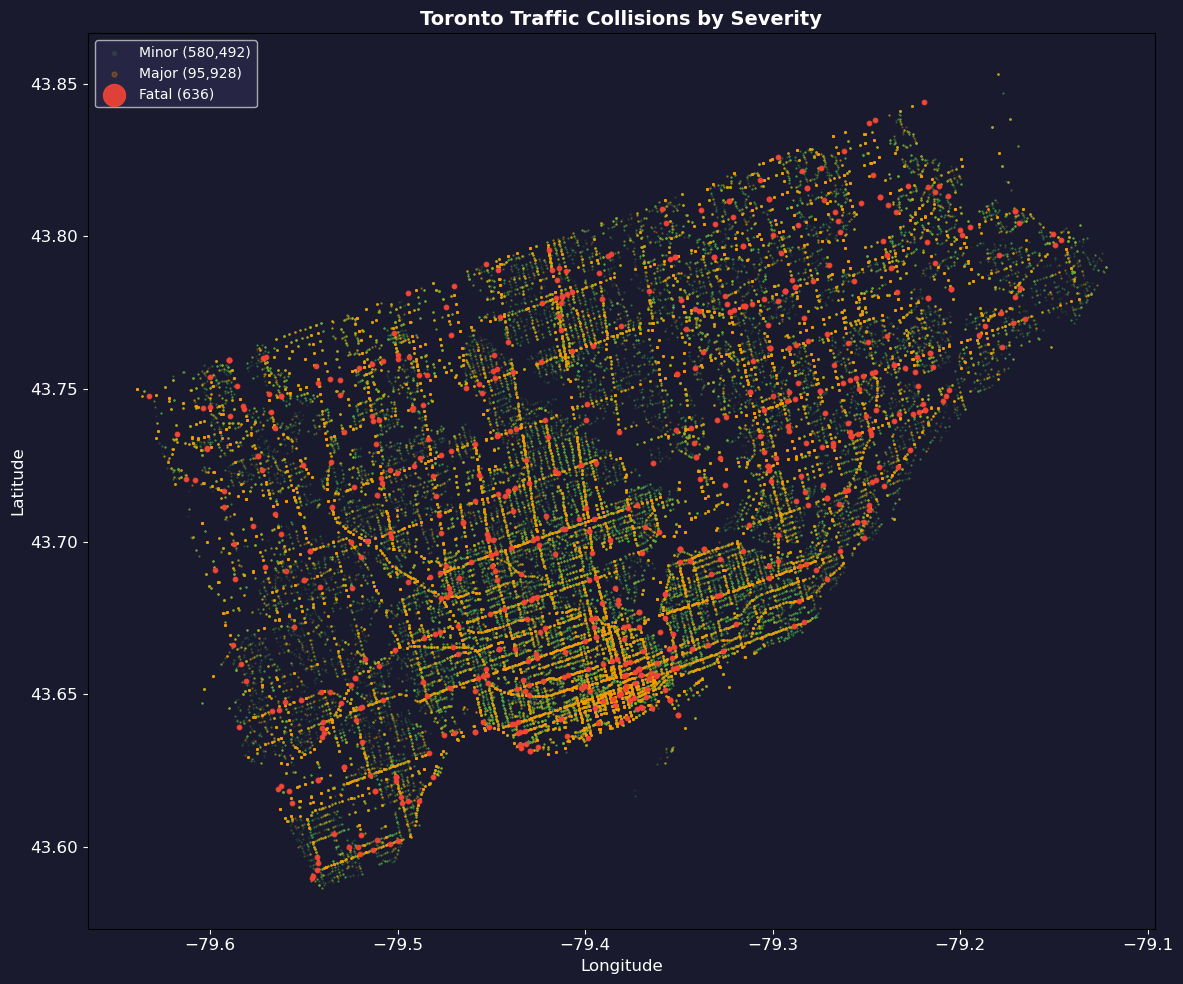

Static map saved!


In [29]:
# Static map — renders inside VS Code notebook
fig, ax = plt.subplots(figsize=(12, 10))

minor = df[df['severity']==0][['LAT_WGS84','LONG_WGS84']].dropna()
major = df[df['severity']==1][['LAT_WGS84','LONG_WGS84']].dropna()
fatal = df[df['severity']==2][['LAT_WGS84','LONG_WGS84']].dropna()

ax.scatter(minor['LONG_WGS84'], minor['LAT_WGS84'],
           s=0.3, alpha=0.15, color='#4CAF50', label=f'Minor ({len(minor):,})')
ax.scatter(major['LONG_WGS84'], major['LAT_WGS84'],
           s=0.5, alpha=0.25, color='#FF9800', label=f'Major ({len(major):,})')
ax.scatter(fatal['LONG_WGS84'], fatal['LAT_WGS84'],
           s=10,  alpha=0.9,  color='#F44336', label=f'Fatal ({len(fatal):,})')

ax.set_title('Toronto Traffic Collisions by Severity', fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.legend(markerscale=5, fontsize=10, facecolor='#2a2a4a', labelcolor='white')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_17_static_collision_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Static map saved!')

---
## Step 6 — Interactive Folium Maps (saved as HTML)

These save as HTML files. Open them by double-clicking in Windows Explorer or run the browser cell below.

In [30]:
# Map 1: All collisions heatmap
coords_all = df[['LAT_WGS84','LONG_WGS84']].dropna().values.tolist()
m_all = folium.Map(location=[43.70,-79.42], zoom_start=11, tiles='CartoDB positron')
HeatMap(coords_all, radius=10, blur=15, max_zoom=13).add_to(m_all)
folium.LayerControl().add_to(m_all)
m_all.save(f'{MAPS_FOLDER}map_1_all_collisions_heatmap.html')
print(f'Saved map_1 ({len(coords_all):,} points)')

Saved map_1 (677,056 points)


In [31]:
# Map 2: Fatal collisions heatmap
fatal_df = df[df['severity']==2][['LAT_WGS84','LONG_WGS84']].dropna().copy()
m_fatal = folium.Map(location=[43.70,-79.42], zoom_start=11, tiles='CartoDB positron')
HeatMap(fatal_df.values.tolist(), radius=15, blur=20,
        gradient={0.2:'blue', 0.5:'orange', 1.0:'red'}).add_to(m_fatal)
for _, row in fatal_df.iterrows():
    folium.CircleMarker(
        [row['LAT_WGS84'], row['LONG_WGS84']],
        radius=4, color='red', fill=True, fill_opacity=0.7
    ).add_to(m_fatal)
m_fatal.save(f'{MAPS_FOLDER}map_2_fatal_collisions.html')
print(f'Saved map_2 ({len(fatal_df):,} fatal locations)')

Saved map_2 (636 fatal locations)


---
## Step 7 — DBSCAN Spatial Clustering

In [32]:
# Find spatial hotspot clusters using DBSCAN
coords_rad = np.radians(fatal_df.values)
db = DBSCAN(eps=300/6371000, min_samples=3, metric='haversine').fit(coords_rad)
fatal_df = fatal_df.copy()
fatal_df['cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f'DBSCAN found {n_clusters} hotspot zones')
print(f'Noise points (isolated fatals): {(db.labels_==-1).sum()}')
print('\nTop 10 clusters by size:')
print(fatal_df[fatal_df['cluster']>=0]['cluster'].value_counts().head(10).to_string())

DBSCAN found 36 hotspot zones
Noise points (isolated fatals): 499

Top 10 clusters by size:
cluster
13    7
3     6
24    6
1     5
17    5
9     5
15    5
7     5
18    4
2     4


In [33]:
# Map 3: DBSCAN clusters
colors = ['red','blue','green','purple','orange','darkred','darkblue',
          'darkgreen','cadetblue','darkpurple','pink','lightblue','lightgreen']
m_clust = folium.Map(location=[43.70,-79.42], zoom_start=11, tiles='CartoDB positron')
for _, row in fatal_df.iterrows():
    cid   = row['cluster']
    color = 'gray' if cid == -1 else colors[int(cid) % len(colors)]
    folium.CircleMarker(
        [row['LAT_WGS84'], row['LONG_WGS84']],
        radius=6, color=color, fill=True,
        fill_opacity=0.8, popup=f'Cluster {cid}'
    ).add_to(m_clust)
m_clust.save(f'{MAPS_FOLDER}map_3_dbscan_clusters.html')
print('Saved map_3_dbscan_clusters.html')

Saved map_3_dbscan_clusters.html


In [34]:
# Open all maps in browser
webbrowser.open(os.path.abspath(f'{MAPS_FOLDER}map_1_all_collisions_heatmap.html'))
webbrowser.open(os.path.abspath(f'{MAPS_FOLDER}map_2_fatal_collisions.html'))
webbrowser.open(os.path.abspath(f'{MAPS_FOLDER}map_3_dbscan_clusters.html'))
print('Maps opened in browser!')
print(f'Or navigate to: {os.path.abspath(MAPS_FOLDER)}')

Maps opened in browser!
Or navigate to: c:\Users\nishr\OneDrive - George Brown College\Documents\TMU\MRP - Final Sem\Maps


---
## Step 8 — Final Project Summary

In [36]:
y = df['severity']
print('='*65)
print('  TORONTO COLLISION SEVERITY — FINAL SUMMARY')
print('='*65)

print(f'\n DATASET')
print(f'  Total records : {len(df):,}')
print(f'  Features used : {X_test.shape[1]}')

print(f'\n CLASS DISTRIBUTION')
for k in [0,1,2]:
    n = (y==k).sum()
    print(f'  {severity_labels[k]:8s}: {n:,} ({n/len(y)*100:.1f}%)')

print(f'\n MODEL RESULTS')
print(results_df.to_string(index=False))

print(f'\n BEST MODEL: {best_model_name}')

print(f'\n TOP FATAL RISK FACTORS (SHAP):')
for i, row in shap_importance.iterrows():
    print(f'  {i+1:2d}. {row["Feature"]:35s} {row["Mean |SHAP|"]:.4f}')

print(f'\n HOTSPOT ZONES FOUND: {n_clusters}')

print(f'\n OUTPUT FILES')
print(f'  Plots  → {PLOTS_FOLDER}')
print(f'  Maps   → {MAPS_FOLDER}')
print(f'  Models → {MODELS_FOLDER}')
print('='*65)
print('\n✅ Project Complete!')

  TORONTO COLLISION SEVERITY — FINAL SUMMARY

 DATASET
  Total records : 677,056
  Features used : 37

 CLASS DISTRIBUTION
  Minor   : 580,492 (85.7%)
  Major   : 95,928 (14.2%)
  Fatal   : 636 (0.1%)

 MODEL RESULTS
              Model  Accuracy  F1 Weighted  F1 Macro  ROC-AUC
            XGBoost    0.9002       0.8920    0.5193   0.7839
      Random Forest    0.8972       0.8911    0.5148   0.7809
  Gradient Boosting    0.8979       0.8904    0.5126   0.7823
     Neural Network    0.8700       0.8731    0.4973   0.7624
Logistic Regression    0.8652       0.8663    0.4765   0.7452

 BEST MODEL: XGBoost

 TOP FATAL RISK FACTORS (SHAP):
   1. OCC_YEAR                            0.3916
   2. season_Spring                       0.3444
   3. season_Fall                         0.2946
   4. HOOD_158                            0.2642
   5. OCC_MONTH                           0.2556
   6. OCC_DOW_Friday                      0.2515
   7. season_Summer                       0.2374
   8. PEDESTR